In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Data/errors_indicators.csv")

C:\Users\ignacio.delatorre\AppData\Local\Temp\ipykernel_9728\4049374003.py:1: DtypeWarning: Columns (1,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Data/errors_indicators.csv")


In [3]:
df_mae = df[['query', 'MAE']]
df_mae_ext = pd.get_dummies(
    df_mae,
    columns=["query"],
    dtype="int8"
)

df_mae_ext.columns = df_mae_ext.columns.str.replace("^query_", "", regex=True)

In [31]:
df_mae = df[['query', 'MAE','spearman_corr']]
df_mae_ext = pd.get_dummies(
    df_mae,
    columns=["query"],
    dtype="int8"
)

df_mae_ext.columns = df_mae_ext.columns.str.replace("^query_", "", regex=True)

#### Error distribution by queries

MAE Total: 474035489502.73694
nonCO2 emissions by tech (excluding resource production)         6.905053e-07
nonCO2 emissions by subsector (excluding resource production)    2.728129e-07
inputs by tech                                                   2.088114e-07
input-output coefficients by tech                                2.087966e-07
outputs by tech                                                  1.452275e-07
profit rate                                                      6.507108e-08
land leaf shares                                                 6.507108e-08
detailed land allocation                                         6.507108e-08
LUC emissions by region                                          6.507108e-08
LUC emissions by LUT                                             6.507108e-08
inputs by sector                                                 6.470191e-08
nonCO2 emissions by sector (excluding resource production)       6.469769e-08
ag tech yield                     

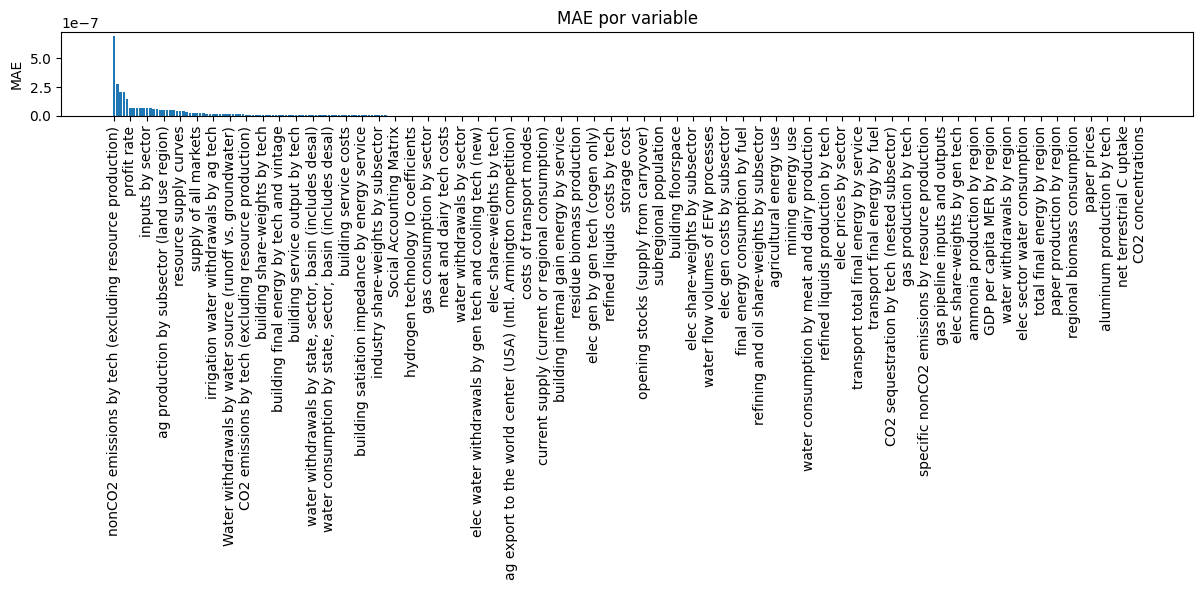

In [26]:
total_mae = df_mae_ext.sum()

print('MAE Total:', total_mae['MAE'])

MAE_distr = total_mae/total_mae['MAE']
MAE_distr = MAE_distr.drop('MAE')  # quitas el total si está dentro
MAE_distr = MAE_distr.sort_values(ascending=False)
print(MAE_distr.head(20))
plt.figure(figsize=(12,6))
plt.bar(MAE_distr.index, MAE_distr.values)

step = 5  # cada 5 etiquetas
xticks = MAE_distr.index[::step]

plt.xticks(xticks, rotation=90)
plt.ylabel('MAE')
plt.title('MAE por variable')
plt.tight_layout()
plt.show()

CO2 concentrations                                                0.000064
total climate forcing                                             0.000064
supply of a specific market                                       0.000064
global mean temperature                                           0.000064
net terrestrial C uptake                                          0.000064
                                                                   ...    
outputs by tech                                                   4.394954
input-output coefficients by tech                                 6.318716
inputs by tech                                                    6.319163
nonCO2 emissions by subsector (excluding resource production)     8.256012
nonCO2 emissions by tech (excluding resource production)         20.896445
Length: 311, dtype: float64


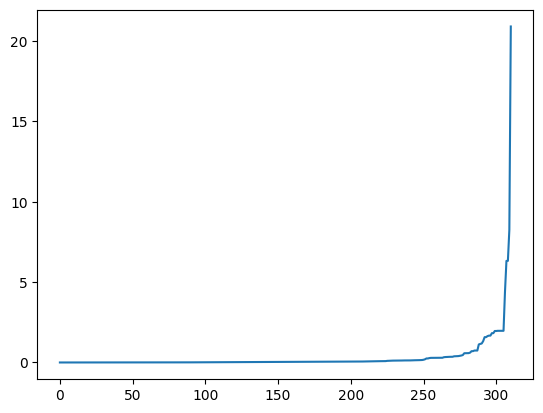

In [27]:
def porcentaje_no_cero(df):
    # máscara booleana: True si es != 0 y no es NaN
    mask = df.ne(0) & df.notna()
    
    # proporción por columna
    return mask.sum() / df.notna().sum() * 100

porcentajes = porcentaje_no_cero(df_mae_ext.drop('MAE', axis = 1)).sort_values()
print(porcentajes)



plt.plot(porcentajes.values)
plt.show()

#### Dimensionality Reduction

Eliminar aquellas que tienen menor magnitud

In [4]:
threshold = 0.01 

X = df_mae_ext.drop('MAE', axis = 1)
y = df_mae_ext['MAE']
mask_1 = X.eq(1)

porc_1 = mask_1.sum() / len(X)

X_new = X.loc[:, porc_1 >= threshold]
print(len(X.columns), 'variables ->',len(X_new.columns), 'variables')
df_mae_ext_reduct = pd.concat([y,X_new], axis = 1)

311 variables -> 23 variables


correlaciones

0.36987154552827173


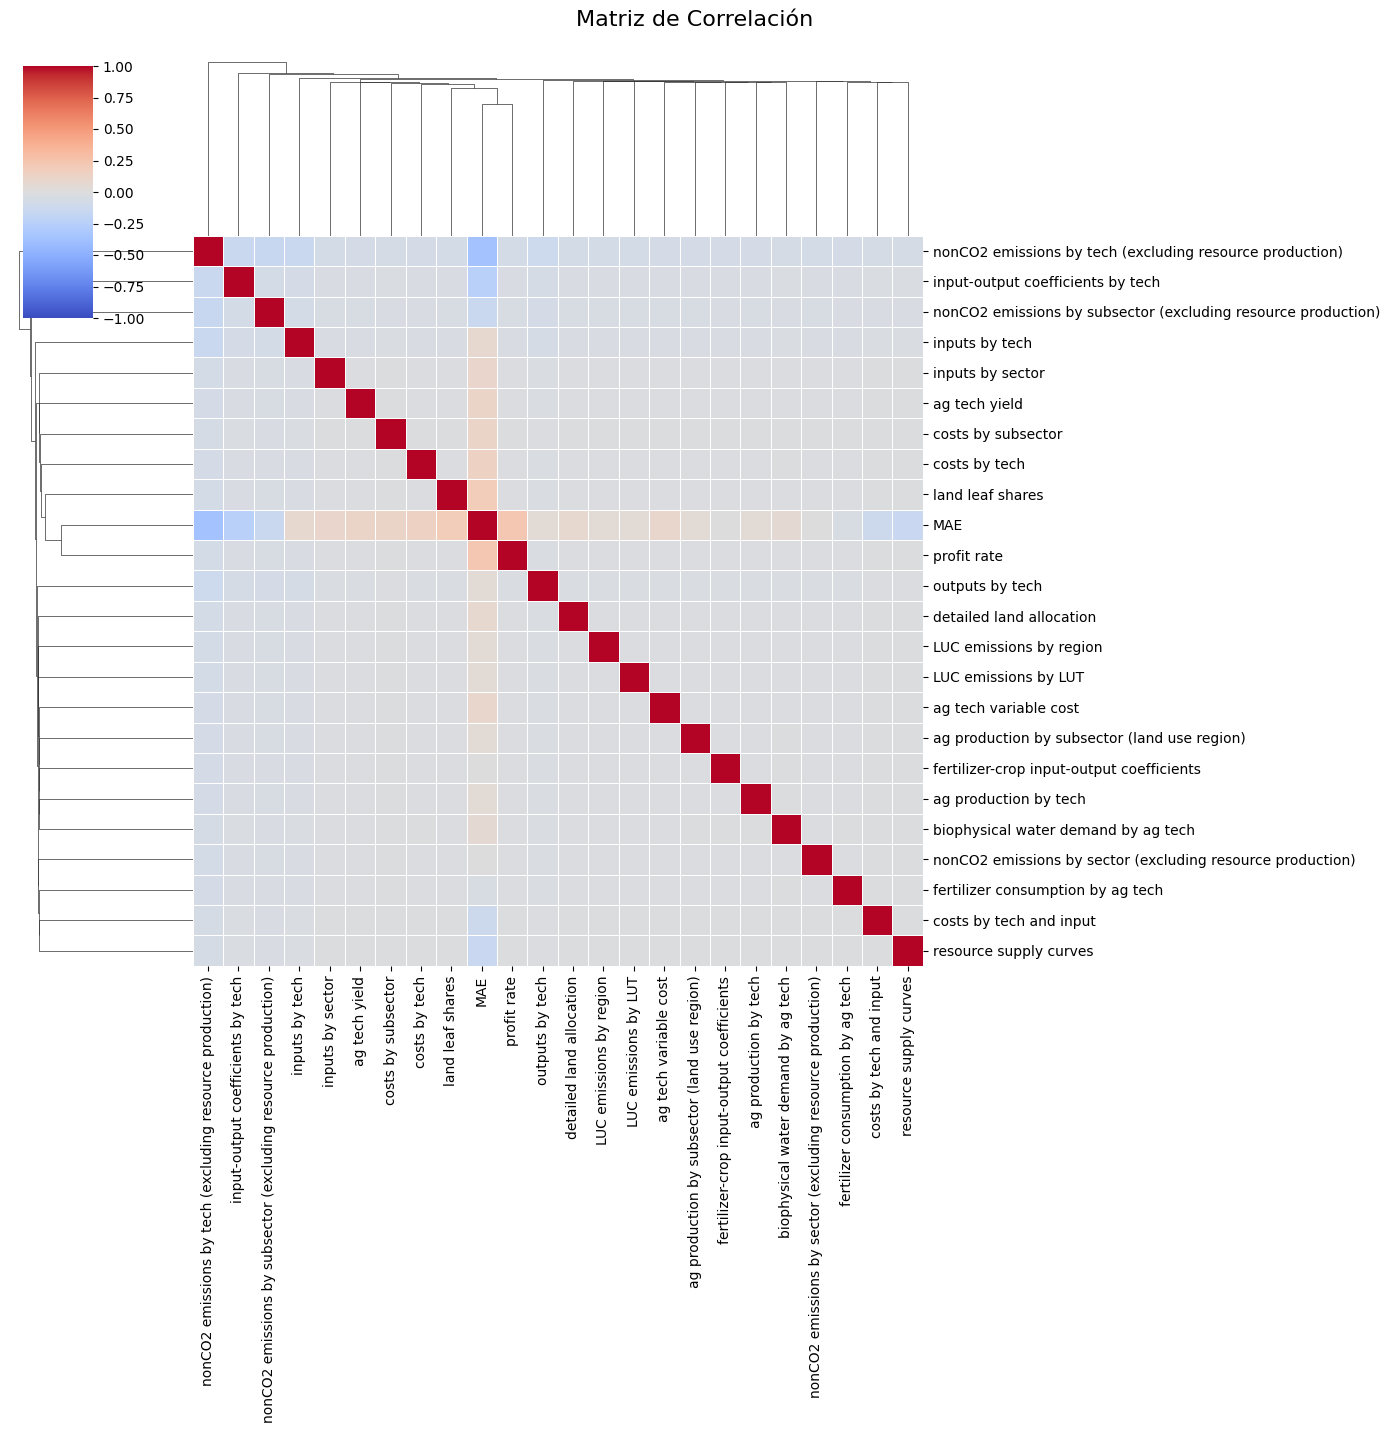

In [60]:
corr = df_mae_ext_reduct.corr(method='spearman')  

cluster = sns.clustermap(corr,
                         cmap='coolwarm',
                         vmin=-1, vmax=1,
                         figsize=(14, 14),
                         linewidths=0.5,
                         annot=False,
                         cbar_kws={"shrink": 0.7}
)
cluster.fig.suptitle('Matriz de Correlación', y=1.02, fontsize=16)

corr_no_diag = corr.where(~np.eye(corr.shape[0], dtype=bool))

max_corr = corr_no_diag.abs().max().max()

print(max_corr)

#### Bayesian network

In [30]:
len(X.columns)

23

In [31]:
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BIC
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout


c:\Users\ignacio.delatorre\AppData\Local\miniconda3\envs\py_env_torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
X_bn = X

hc = HillClimbSearch(X_bn)


best_model = hc.estimate(
    scoring_method=BIC(X_bn),
    blacklist=[...],
    max_indegree=2
)
G = nx.DiGraph(best_model.edges())



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'LUC emissions by LUT': 'N', 'LUC emissions by region': 'N', 'ag production by subsector (land use region)': 'N', 'ag production by tech': 'N', 'ag tech variable cost': 'N', 'ag tech yield': 'N', 'biophysical water demand by ag tech': 'N', 'costs by subsector': 'N', 'costs by tech': 'N', 'costs by tech and input': 'N', 'detailed land allocation': 'N', 'fertilizer consumption by ag tech': 'N', 'fertilizer-crop input-output coefficients': 'N', 'input-output coefficients by tech': 'N', 'inputs by sector': 'N', 'inputs by tech': 'N', 'land leaf shares': 'N', 'nonCO2 emissions by sector (excluding resource production)': 'N', 'nonCO2 emissions by subsector (excluding resource production)': 'N', 'nonCO2 emissions by tech (excluding resource production)': 'N', 'outputs by tech': 'N', 'profit rate': 'N', 'resource supply curves': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unorder

TypeError: HillClimbSearch.estimate() got an unexpected keyword argument 'blacklist'

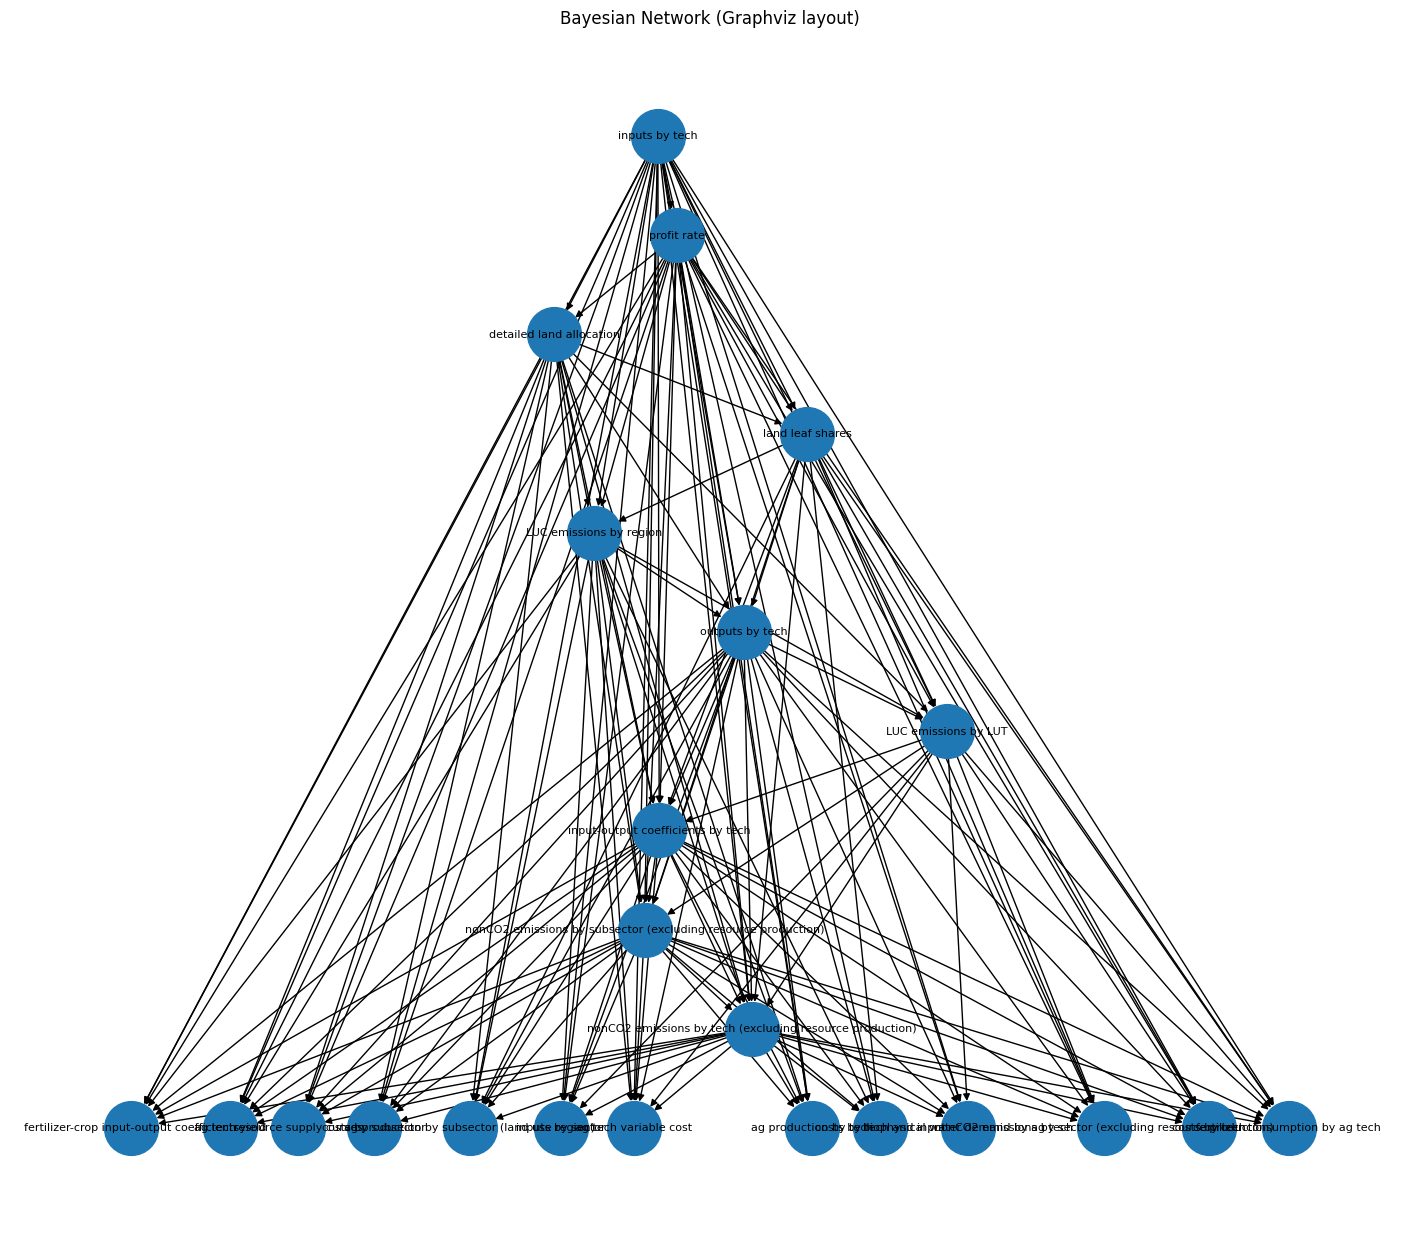

In [ ]:
pos = graphviz_layout(G, prog="dot")

plt.figure(figsize=(14, 12))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=8,
    arrows=True
)

plt.title("Bayesian Network (Graphviz layout)")
plt.show()

In [ ]:
pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [ ]:

pos = graphviz_layout(G, prog="dot")

edges = list(best_model.edges())

strong_edges = [e for e in edges if weight[e] > 0.2]


### Predicción

##### Sobre error

In [5]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import sys

In [6]:
target = "MAE"
features = df_mae_ext_reduct.columns.drop(target)


X = df_mae_ext_reduct[features]
y = np.log1p(df_mae_ext_reduct[target])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. model
model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=10,
    gamma=1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

# 4. metrics
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

r2_train = r2_score(y_train, train_pred)
r2_test = r2_score(y_test, test_pred)


mae_train = mean_absolute_error(y_train, train_pred)
mae_test = mean_absolute_error(y_test, test_pred)

importances = model.feature_importances_


imp_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print('R^2 train: ',r2_train)
print('R^2 test: ',r2_test)
print('MAE train:',mae_train)
print('MAE test:',mae_test)
print(imp_df)


R^2 train:  0.7981197916052291
R^2 test:  0.8021021528323051
MAE train: 0.22747438577254045
MAE test: 0.22404415298781086
                                              feature  importance
21                                        profit rate    0.908531
19  nonCO2 emissions by tech (excluding resource p...    0.016283
18  nonCO2 emissions by subsector (excluding resou...    0.013116
15                                     inputs by tech    0.011294
13                  input-output coefficients by tech    0.010327
17  nonCO2 emissions by sector (excluding resource...    0.004971
0                                LUC emissions by LUT    0.004486
1                             LUC emissions by region    0.004447
8                                       costs by tech    0.003795
16                                   land leaf shares    0.002663
11                  fertilizer consumption by ag tech    0.002375
12          fertilizer-crop input-output coefficients    0.002213
2        ag producti

##### Interpretación

In [7]:
import statsmodels.api as sm

target = "MAE"
y = np.log1p(df_mae_ext_reduct[target])
X = df_mae_ext_reduct['profit rate']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    MAE   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                 6.016e+06
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:22:12   Log-Likelihood:            -2.1691e+06
No. Observations:             1566410   AIC:                         4.338e+06
Df Residuals:                 1566408   BIC:                         4.338e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1222      0.001    156.629      

Es decir, $log(1 + MAE) = 0.1222 + 13.6317 (Profit Rate)$ por lo que:

$1 + MAE = e^{0.1222 + 13.63 (Profit Rate)}$

$\frac{\vartriangle MAE}{1 + MAE} \approx e^{13.631 * Profit Rate} $

o de otra forma:
Si profit rate aumenta 1 punto porcentual, MAE sube aproximadamente un 14.6%



Ya vemos que profit rate es una variable que afecta al error en mayor medida. Sin embargo, existen otras variables que, aunque no afecten directamente al error, lo hacen a través de profit rate?

### Variables subyacente a través de variable fundamental

##### Estimación variable profit rate

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_predict


y = df_mae_ext["profit rate"]
X = df_mae_ext.drop(columns=["profit rate", "MAE"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    oob_score=True,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


y_test_proba = rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

J = tpr - fpr
ix = np.argmax(J)
best_thresh = thresholds[ix]
print("Best threshold:", best_thresh)

y_train_pred = rf.predict(X_train)
y_test_pred = (y_test_proba > best_thresh).astype(int)





print("OOB score:", rf.oob_score_)
print(classification_report(y_test, y_test_pred))

profit_hat = cross_val_predict(
    rf,
    X,
    y,
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

Best threshold: 0.9989033291404771
OOB score: 0.9992235430059818
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    307113
           1       0.00      0.00      0.00      6169

    accuracy                           0.98    313282
   macro avg       0.49      0.50      0.50    313282
weighted avg       0.96      0.98      0.97    313282



c:\Users\ignacio.delatorre\AppData\Local\miniconda3\envs\py_env_torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ignacio.delatorre\AppData\Local\miniconda3\envs\py_env_torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ignacio.delatorre\AppData\Local\miniconda3\envs\py_env_torch\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

#### Variables latentes

In [11]:
residual_profit = df_mae_ext_reduct["profit rate"] - profit_hat

In [13]:
X_second = pd.DataFrame({
    #"profit_hat": profit_hat,
    "residual_profit": residual_profit
})

y = np.log1p(df_mae_ext_reduct['MAE'])

X_second = sm.add_constant(X_second)

model = sm.OLS(y, X_second).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    MAE   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                 3.183e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:33:48   Log-Likelihood:            -3.3886e+06
No. Observations:             1566410   AIC:                         6.777e+06
Df Residuals:                 1566408   BIC:                         6.777e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8057      0.003    2

In [79]:
MAE = df_mae_ext['MAE']

X_second = pd.DataFrame({
    "profit_hat": profit_hat,
    "residual_profit": residual_profit
})

#X_second = pd.concat([X_second, X], axis=1)

gbm = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=10,
    gamma=1,

    reg_alpha=0.1,
    reg_lambda=1.0,

    n_jobs=-1,
    random_state=42
)
gbm.fit(X_second, MAE)


MAE_pred = gbm.predict(X_second)

r2 = r2_score(MAE, MAE_pred)


importances = gbm.feature_importances_


imp_df = pd.DataFrame({
    "feature": X_second.columns,
    "importance": gbm.feature_importances_
}).sort_values("importance", ascending=False)

print('R^2: ',r2)
print(imp_df)


R^2:  4.1680742250194136e-05
           feature  importance
1  residual_profit         1.0
0       profit_hat         0.0


In [76]:
MAE_pred = gbm.predict(X_second)

r2 = r2_score(MAE, MAE_pred)


importances = gbm.feature_importances_


imp_df = pd.DataFrame({
    "feature": X_second.columns,
    "importance": gbm.feature_importances_
}).sort_values("importance", ascending=False)

print('R^2: ',r2)
print(imp_df)

R^2:  7.8714681306713e-05
                                              feature  importance
14                                      costs by tech    0.818930
27                              prices of all markets    0.086553
1                                     residual_profit    0.057737
3   nonCO2 emissions by tech (excluding resource p...    0.005292
4   nonCO2 emissions by subsector (excluding resou...    0.003028
6                                      inputs by tech    0.002936
5                   input-output coefficients by tech    0.002933
7                                     outputs by tech    0.002534
9                                    land leaf shares    0.001521
12                               LUC emissions by LUT    0.001510
8                            detailed land allocation    0.001406
11                                   inputs by sector    0.001347
10                            LUC emissions by region    0.001328
13  nonCO2 emissions by sector (excluding resource